# Notebook 04 - Feature Validation

Notebook này thực hiện đánh giá và xác thực các đặc trưng trong bộ dữ liệu khảo sát sinh viên Việt Nam nhằm xác định các biến có chất lượng dữ liệu tốt, mức độ liên quan phù hợp và khả năng sử dụng trong các bước phân tích tiếp theo của nghiên cứu.

Nghiên cứu sử dụng hai bộ dữ liệu:

- Bộ dữ liệu quốc tế (5 triệu mẫu) dùng để xây dựng mô hình dự đoán và khai thác tri thức bằng Explainable AI.
- Bộ dữ liệu khảo sát sinh viên Việt Nam dùng để kiểm chứng và áp dụng khung đánh giá Digital Burnout trong bối cảnh sinh viên Việt Nam.

Notebook bao gồm các bước:

1. Kiểm tra tổng quan các nhóm đặc trưng.
2. Đánh giá mối quan hệ giữa các biến.
3. Kiểm định mức độ phù hợp của đặc trưng.
4. Phân tích mức độ trùng lặp thông tin giữa các biến.
5. Xếp hạng và lựa chọn tập đặc trưng phù hợp.

# 0. Set Up

Thiết lập môi trường thực thi cho Notebook 04 - Feature Validation.

In [82]:
# Import các thư viện phục vụ phân tích dữ liệu

import pandas as pd
import numpy as np

# Import thư viện trực quan hóa

import matplotlib.pyplot as plt
import seaborn as sns

# Import thư viện kiểm định thống kê

from scipy import stats

# Import thư viện xử lý đường dẫn

import os
from pathlib import Path

# Cấu hình cảnh báo

import warnings
warnings.filterwarnings("ignore")


# Thiết lập hiển thị dữ liệu

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)


# Thiết lập kích thước biểu đồ mặc định

plt.rcParams["figure.figsize"] = (10, 6)

# 1. Load Dataset

Đọc bộ dữ liệu khảo sát sinh viên Việt Nam đã được làm sạch từ Notebook 02 và kiểm tra cấu trúc dữ liệu đầu vào trước khi thực hiện Feature Validation.

In [83]:
# Thiết lập thư mục gốc dự án

project_root = Path("../..").resolve()

# Thiết lập đường dẫn dữ liệu

input_path = (
    project_root
    / "data"
    / "processed"
    / "vietnam_dataset"
    / "vn_digital_burnout_cleaned.csv"
)

# Đọc dữ liệu

df = pd.read_csv(input_path)

print("Kích thước dữ liệu:", df.shape)

Kích thước dữ liệu: (590, 23)


In [84]:
# Hiển thị một số bản ghi đầu tiên của dữ liệu

df.head()

,gender,birth_year,education_stage,work_mode,device_usage_type,daily_screen_time,social_media_hours,doomscrolling_duration,late_night_device_usage,notification_count,smartphone_unlocks,app_switch_frequency,concentration_score,distraction_frequency,focus_sessions,deep_work_hours,task_completion_rate,sleep_hours,sleep_quality,motivation_level,emotional_exhaustion,stress_level,mental_fatigue
0,Nam,2006 - 2008,Sinh viên đại học / cao đẳng (năm 3-4+),Hoàn toàn trực tiếp (đến trường / văn phòng ≥ ...,"Chủ yếu để giải trí (mạng xã hội, game, xem phim)",2,2,4,3,0,1,1,1,3,2,0,3,1,1,10,1,1,4
1,Nữ,2006 - 2008,Sinh viên đại học / cao đẳng (năm 1-2),"Kết hợp hybrid (2-3 ngày trực tiếp, còn lại on...",Cân bằng cả học lẫn giải trí,3,1,1,1,1,1,2,6,1,1,1,3,3,9,9,5,5,4
2,Nữ,2006 - 2008,Sinh viên đại học / cao đẳng (năm 3-4+),Hoàn toàn trực tiếp (đến trường / văn phòng ≥ ...,"Chủ yếu để học (LMS, tài liệu, nghiên cứu)",4,2,2,3,3,2,3,7,1,3,2,2,3,8,6,5,5,5
3,Nữ,2006 - 2008,Sinh viên đại học / cao đẳng (năm 1-2),"Tự do, không cố định lịch trình",Cân bằng cả học lẫn giải trí,3,2,1,3,1,1,1,6,1,3,1,3,1,4,8,4,5,3
4,Nữ,2009 - 2012,Học sinh THPT,Hoàn toàn trực tiếp (đến trường / văn phòng ≥ ...,"Chủ yếu để giải trí (mạng xã hội, game, xem phim)",4,3,4,3,2,1,1,7,1,2,1,0,3,8,4,2,2,4


In [85]:
# Kiểm tra thông tin tổng quan của dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590 entries, 0 to 589
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   gender                   590 non-null    object
 1   birth_year               590 non-null    object
 2   education_stage          590 non-null    object
 3   work_mode                590 non-null    object
 4   device_usage_type        590 non-null    object
 5   daily_screen_time        590 non-null    int64 
 6   social_media_hours       590 non-null    int64 
 7   doomscrolling_duration   590 non-null    int64 
 8   late_night_device_usage  590 non-null    int64 
 9   notification_count       590 non-null    int64 
 10  smartphone_unlocks       590 non-null    int64 
 11  app_switch_frequency     590 non-null    int64 
 12  concentration_score      590 non-null    int64 
 13  distraction_frequency    590 non-null    int64 
 14  focus_sessions           590 non-null    i

In [86]:
# Hiển thị danh sách các biến trong dataset

print("Số lượng biến:", len(df.columns))

print("\nDanh sách biến:")
for column in df.columns:
    print(column)

Số lượng biến: 23

Danh sách biến:
gender
birth_year
education_stage
work_mode
device_usage_type
daily_screen_time
social_media_hours
doomscrolling_duration
late_night_device_usage
notification_count
smartphone_unlocks
app_switch_frequency
concentration_score
distraction_frequency
focus_sessions
deep_work_hours
task_completion_rate
sleep_hours
sleep_quality
motivation_level
emotional_exhaustion
stress_level
mental_fatigue


# 2. Feature Overview

Phân loại và kiểm tra tổng quan các nhóm đặc trưng trong bộ dữ liệu khảo sát sinh viên Việt Nam nhằm xác định cấu trúc biến trước khi thực hiện Feature Validation.

Phần này thực hiện:

- Xác định các nhóm đặc trưng nghiên cứu.
- Kiểm tra kiểu dữ liệu của các biến.
- Đánh giá mức độ đầy đủ của dữ liệu.
- Tổng hợp số lượng đặc trưng theo từng nhóm.

## 2.1 Feature Groups Definition

Xây dựng cấu trúc nhóm đặc trưng dựa trên mô hình lý thuyết Digital Burnout đã được xác định trong nghiên cứu.

Việc phân nhóm giúp đảm bảo các đặc trưng được đánh giá theo đúng vai trò nghiên cứu thay vì chỉ xem xét từng biến riêng lẻ.

In [87]:
# Định nghĩa nhóm đặc trưng nghiên cứu

feature_groups = {

    "digital_exposure_features": [
        "daily_screen_time",
        "social_media_hours",
        "doomscrolling_duration",
        "late_night_device_usage",
        "notification_count",
        "smartphone_unlocks",
        "app_switch_frequency"
    ],

    "cognitive_performance_features": [
        "concentration_score",
        "distraction_frequency",
        "focus_sessions",
        "deep_work_hours",
        "task_completion_rate",
        "motivation_level"
    ],

    "sleep_recovery_features": [
        "sleep_hours",
        "sleep_quality"
    ],

    "psychological_features": [
        "emotional_exhaustion",
        "stress_level",
        "mental_fatigue"
    ],

    "context_features": [
        "work_mode",
        "device_usage_type"
    ],

    "demographic_features": [
        "gender",
        "birth_year",
        "education_stage"
    ]
}

# Kiểm tra số lượng biến trong từng nhóm

for group, features in feature_groups.items():
    print(group, ":", len(features), "features")

digital_exposure_features : 7 features
cognitive_performance_features : 6 features
sleep_recovery_features : 2 features
psychological_features : 3 features
context_features : 2 features
demographic_features : 3 features


Các biến trong dataset được phân thành 6 nhóm đặc trưng chính:

- Digital Exposure: phản ánh mức độ tiếp xúc và hành vi sử dụng thiết bị số.
- Cognitive Performance: phản ánh khả năng tập trung, duy trì hiệu suất và quản lý công việc.
- Sleep & Recovery: phản ánh khả năng phục hồi thông qua giấc ngủ.
- Psychological Features: phản ánh các biểu hiện liên quan đến kiệt sức tâm lý.
- Context Features: mô tả bối cảnh sử dụng thiết bị và môi trường học tập/làm việc.
- Demographic Features: cung cấp thông tin nền để phục vụ phân tích so sánh.

Các nhóm đặc trưng này sẽ được sử dụng làm cơ sở cho các bước đánh giá tương quan, kiểm định thống kê và xếp hạng đặc trưng ở các phần tiếp theo.

## 2.2 Data Type Analysis

Kiểm tra kiểu dữ liệu của các biến trong bộ dữ liệu nhằm xác định cấu trúc dữ liệu đầu vào trước khi thực hiện các phương pháp đánh giá đặc trưng.

Việc xác định kiểu dữ liệu giúp lựa chọn phương pháp phân tích phù hợp:

- Biến số được sử dụng trong phân tích tương quan và thống kê mô tả.
- Biến phân loại được xem xét thông qua các phương pháp kiểm định phù hợp.

In [88]:
# Kiểm tra kiểu dữ liệu của các biến

dtype_summary = (
    df.dtypes
    .reset_index()
)

dtype_summary.columns = [
    "feature",
    "data_type"
]


dtype_summary

,feature,data_type
0,gender,object
1,birth_year,object
2,education_stage,object
3,work_mode,object
4,device_usage_type,object
5,daily_screen_time,int64
6,social_media_hours,int64
7,doomscrolling_duration,int64
8,late_night_device_usage,int64
9,notification_count,int64


In [89]:
# Tổng hợp số lượng biến theo kiểu dữ liệu

data_type_count = (
    df.dtypes
    .value_counts()
    .reset_index()
)

data_type_count.columns = [
    "data_type",
    "count"
]


data_type_count

,data_type,count
0,int64,18
1,object,5


In [90]:
# Phân tách biến số và biến phân loại

numeric_features = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()


categorical_features = df.select_dtypes(
    include=["object"]
).columns.tolist()


print("Số lượng biến số:", len(numeric_features))
print("Số lượng biến phân loại:", len(categorical_features))

Số lượng biến số: 18
Số lượng biến phân loại: 5


## 2.3 Missing Value Analysis

Đánh giá mức độ đầy đủ của dữ liệu sau bước Cleaning & Preprocessing nhằm xác nhận chất lượng dữ liệu trước khi thực hiện Feature Validation.

In [91]:
# Kiểm tra số lượng giá trị thiếu của từng biến

missing_summary = (
    df.isnull()
    .sum()
    .reset_index()
)

missing_summary.columns = [
    "feature",
    "missing_count"
]


missing_summary

,feature,missing_count
0,gender,0
1,birth_year,0
2,education_stage,0
3,work_mode,0
4,device_usage_type,0
5,daily_screen_time,0
6,social_media_hours,0
7,doomscrolling_duration,0
8,late_night_device_usage,0
9,notification_count,0


In [92]:
# Tính tỷ lệ dữ liệu thiếu của từng biến

missing_summary["missing_rate"] = (
    missing_summary["missing_count"] 
    / len(df)
)

missing_summary.sort_values(
    by="missing_rate",
    ascending=False
)

,feature,missing_count,missing_rate
0,gender,0,0.0
1,birth_year,0,0.0
2,education_stage,0,0.0
3,work_mode,0,0.0
4,device_usage_type,0,0.0
5,daily_screen_time,0,0.0
6,social_media_hours,0,0.0
7,doomscrolling_duration,0,0.0
8,late_night_device_usage,0,0.0
9,notification_count,0,0.0


# 3. Feature Validation

Đánh giá mức độ phù hợp của các đặc trưng trong bộ dữ liệu khảo sát sinh viên Việt Nam nhằm xác định các biến có giá trị sử dụng trong các bước phân tích tiếp theo.

Phần này thực hiện các bước đánh giá:

- Phân tích mối quan hệ giữa các biến.
- Kiểm định mức độ phù hợp của đặc trưng.
- Phân tích mức độ trùng lặp thông tin giữa các biến.
- Xây dựng bảng xếp hạng đặc trưng dựa trên các tiêu chí đánh giá.

## 3.1 Correlation Analysis

Phân tích mức độ liên hệ giữa các đặc trưng dạng số nhằm xác định mối quan hệ tuyến tính giữa các biến trong bộ dữ liệu.

Phân tích tương quan giúp:

- Hiểu mối liên hệ giữa các nhóm đặc trưng.
- Xác định các biến có xu hướng thay đổi cùng nhau.
- Cung cấp cơ sở cho bước phân tích redundancy.

Sử dụng hệ số tương quan Pearson để đo lường mức độ liên hệ giữa các biến số.

Giá trị tương quan nằm trong khoảng:

- Gần 1: tương quan thuận mạnh.
- Gần -1: tương quan nghịch mạnh.
- Gần 0: ít có mối liên hệ tuyến tính.

In [93]:
# Lựa chọn các biến số phục vụ phân tích tương quan

numeric_df = df[numeric_features]

# Tính ma trận tương quan Pearson

correlation_matrix = numeric_df.corr()

# Hiển thị ma trận tương quan

correlation_matrix

,daily_screen_time,social_media_hours,doomscrolling_duration,late_night_device_usage,notification_count,smartphone_unlocks,app_switch_frequency,concentration_score,distraction_frequency,focus_sessions,deep_work_hours,task_completion_rate,sleep_hours,sleep_quality,motivation_level,emotional_exhaustion,stress_level,mental_fatigue
daily_screen_time,1.000000,0.084822,0.123390,0.157144,-0.092157,-0.029278,-0.047139,-0.011685,0.046513,0.035871,0.025515,-0.034881,-0.045434,-0.112451,-0.068746,0.085007,0.105031,0.078940
social_media_hours,0.084822,1.000000,0.119589,0.184121,-0.062583,-0.052726,-0.009668,0.000572,-0.040687,0.006141,-0.020606,-0.092098,0.030701,0.003582,-0.080213,0.080508,0.018537,0.094320
doomscrolling_duration,0.123390,0.119589,1.000000,0.116414,-0.091506,-0.024873,-0.144202,0.068316,0.022657,-0.014935,0.001954,-0.010388,-0.072545,-0.059821,-0.045877,0.122424,0.175836,0.093581
late_night_device_usage,0.157144,0.184121,0.116414,1.000000,-0.073678,-0.053502,-0.099060,0.059132,0.115907,0.099004,0.076890,-0.082654,-0.089155,-0.028792,-0.006035,0.253759,0.184790,0.191662
notification_count,-0.092157,-0.062583,-0.091506,-0.073678,1.000000,0.086468,0.109126,-0.095691,-0.023894,0.034509,-0.102378,0.020852,0.034643,0.024443,0.043637,-0.068050,-0.106634,-0.068589
smartphone_unlocks,-0.029278,-0.052726,-0.024873,-0.053502,0.086468,1.000000,0.099872,-0.061443,-0.113190,0.006450,-0.001308,-0.007390,0.054250,0.008476,0.014926,-0.041055,-0.035682,-0.135232
app_switch_frequency,-0.047139,-0.009668,-0.144202,-0.099060,0.109126,0.099872,1.000000,-0.015872,0.000967,-0.071292,-0.032985,0.029770,-0.056331,0.065827,0.086359,-0.090761,-0.089223,-0.068826
concentration_score,-0.011685,0.000572,0.068316,0.059132,-0.095691,-0.061443,-0.015872,1.000000,-0.069712,0.021443,0.105745,-0.015872,-0.021343,0.053032,0.092512,-0.013997,0.006077,0.014188
distraction_frequency,0.046513,-0.040687,0.022657,0.115907,-0.023894,-0.113190,0.000967,-0.069712,1.000000,0.021353,0.048226,-0.107380,-0.055462,-0.025779,-0.017883,0.094741,0.144781,0.030875
focus_sessions,0.035871,0.006141,-0.014935,0.099004,0.034509,0.006450,-0.071292,0.021443,0.021353,1.000000,-0.057661,-0.106262,-0.001186,-0.142123,-0.117460,0.129189,-0.049276,0.011365


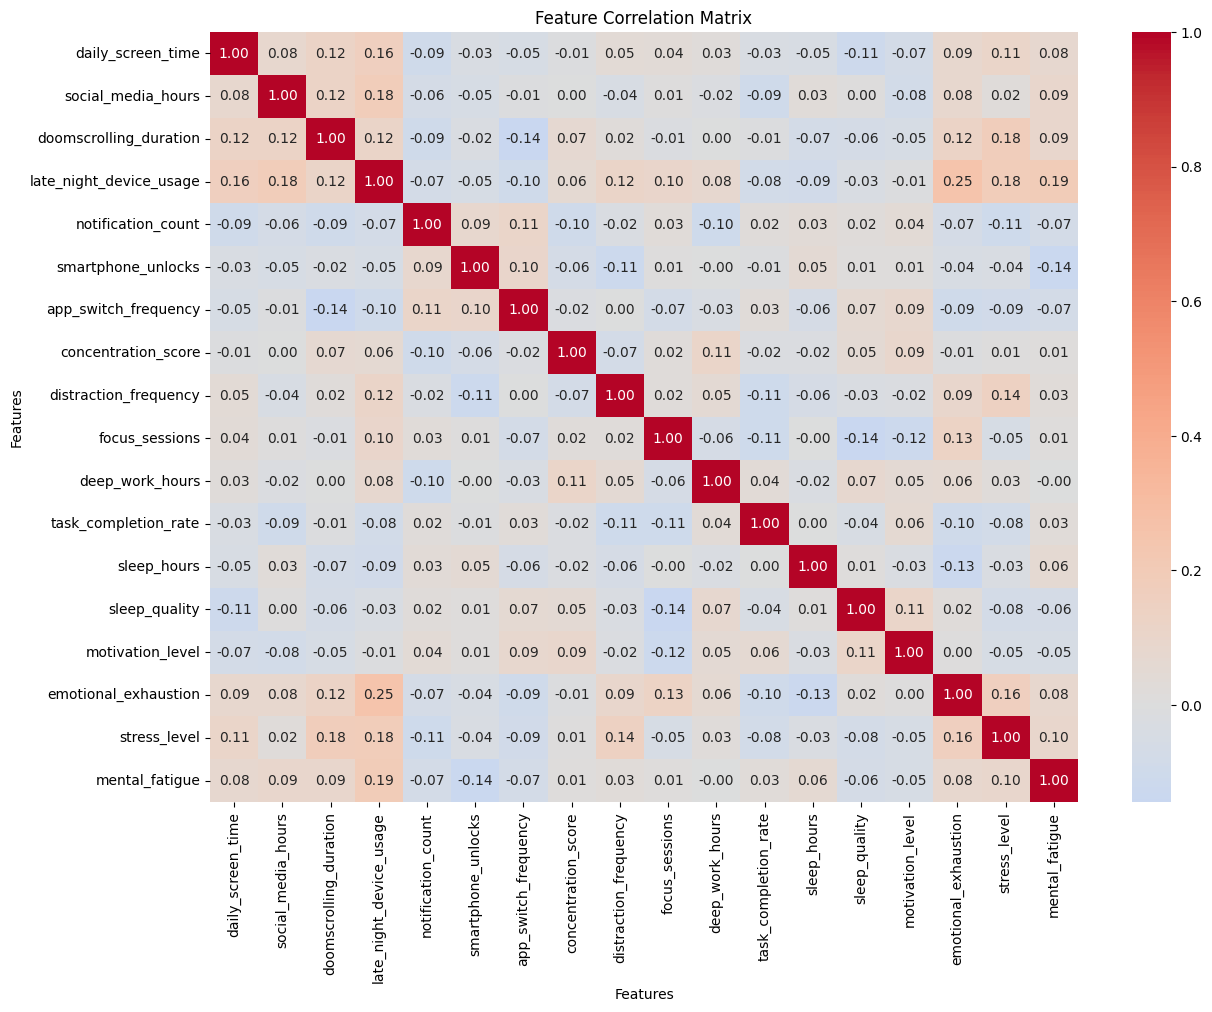

In [94]:
# Trực quan hóa ma trận tương quan

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")
plt.xlabel("Features")
plt.ylabel("Features")

plt.show()

In [95]:
# Tìm các cặp biến có tương quan cao

correlation_pairs = (
    correlation_matrix
    .where(
        np.triu(
            np.ones(correlation_matrix.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .reset_index()
)

correlation_pairs.columns = [
    "feature_1",
    "feature_2",
    "correlation"
]

# Sắp xếp theo trị tuyệt đối của tương quan

correlation_pairs["abs_correlation"] = (
    correlation_pairs["correlation"]
    .abs()
)

correlation_pairs.sort_values(
    by="abs_correlation",
    ascending=False
).head(10)

,feature_1,feature_2,correlation,abs_correlation
59,late_night_device_usage,emotional_exhaustion,0.253759,0.253759
61,late_night_device_usage,mental_fatigue,0.191662,0.191662
60,late_night_device_usage,stress_level,0.184790,0.184790
18,social_media_hours,late_night_device_usage,0.184121,0.184121
46,doomscrolling_duration,stress_level,0.175836,0.175836
150,emotional_exhaustion,stress_level,0.161660,0.161660
2,daily_screen_time,late_night_device_usage,0.157144,0.157144
115,distraction_frequency,stress_level,0.144781,0.144781
36,doomscrolling_duration,app_switch_frequency,-0.144202,0.144202
120,focus_sessions,sleep_quality,-0.142123,0.142123


Kết quả phân tích tương quan Pearson cho thấy các đặc trưng trong bộ dữ liệu khảo sát sinh viên Việt Nam có mức độ tương quan tuyến tính thấp.

Cặp biến có mức tương quan cao nhất là:

- late_night_device_usage và emotional_exhaustion với hệ số tương quan khoảng 0.25.

Các mối quan hệ còn lại đều có hệ số tương quan thấp hơn, cho thấy chưa xuất hiện hiện tượng nhiều biến chứa thông tin tương tự nhau ở mức độ cao.

Điều này cho thấy các đặc trưng trong dataset có mức độ độc lập tương đối và có thể tiếp tục được xem xét trong các bước Feature Validation tiếp theo.

Tuy nhiên, phân tích tương quan chỉ phản ánh mối quan hệ tuyến tính giữa các biến. Vì vậy, cần kết hợp thêm Redundancy Analysis để đánh giá khả năng trùng lặp thông tin giữa các đặc trưng.

## 3.2 Statistical Validation

Đánh giá mức độ khác biệt của các đặc trưng giữa các nhóm sinh viên khác nhau trong bộ dữ liệu khảo sát Việt Nam.

Phân tích thống kê được thực hiện nhằm xác định các đặc trưng có khả năng phản ánh sự khác biệt về hành vi sử dụng thiết bị số, khả năng học tập, giấc ngủ và trạng thái tâm lý giữa các nhóm quan sát.

Phần này thực hiện:

- Kiểm định sự khác biệt của các biến số giữa các nhóm.
- Đánh giá mức độ ý nghĩa thống kê của từng đặc trưng.
- Tổng hợp kết quả kiểm định để phục vụ bước Feature Ranking.

Đối với các biến số:

- Sử dụng Kruskal-Wallis Test.
- Phương pháp này phù hợp với dữ liệu khảo sát dạng ordinal và không yêu cầu giả định phân phối chuẩn.

Các biến nhóm sử dụng để phân tích:

- gender
- education_stage
- work_mode
- device_usage_type

In [96]:
# Xác định các biến phân nhóm sử dụng trong kiểm định thống kê

grouping_features = [
    "gender",
    "education_stage",
    "work_mode",
    "device_usage_type"
]

# Chỉ giữ các biến tồn tại trong dataset

available_grouping_features = [
    feature
    for feature in grouping_features
    if feature in df.columns
]

print("Các biến nhóm sử dụng trong kiểm định:")

for feature in available_grouping_features:
    print(feature)

Các biến nhóm sử dụng trong kiểm định:
gender
education_stage
work_mode
device_usage_type


In [97]:
# Thực hiện kiểm định Kruskal-Wallis cho các biến số

statistical_results = []

for feature in numeric_features:

    for group_feature in available_grouping_features:

        grouped_data = [
            group[feature].values
            for _, group in df.groupby(group_feature)
        ]

        # Kiểm tra số nhóm trước khi kiểm định

        if len(grouped_data) > 1:

            statistic, p_value = stats.kruskal(
                *grouped_data
            )

            statistical_results.append({
                "feature": feature,
                "grouping_feature": group_feature,
                "test": "Kruskal-Wallis",
                "statistic": statistic,
                "p_value": p_value
            })

statistical_results_df = pd.DataFrame(
    statistical_results
)

statistical_results_df.head()

,feature,grouping_feature,test,statistic,p_value
0,daily_screen_time,gender,Kruskal-Wallis,5.612591,0.017832
1,daily_screen_time,education_stage,Kruskal-Wallis,30.656967,0.000029
2,daily_screen_time,work_mode,Kruskal-Wallis,18.301580,0.000381
3,daily_screen_time,device_usage_type,Kruskal-Wallis,11.749124,0.008294
4,social_media_hours,gender,Kruskal-Wallis,15.740593,0.000073


In [98]:
# Đánh dấu kết quả kiểm định có ý nghĩa thống kê

statistical_results_df["significant"] = (
    statistical_results_df["p_value"] < 0.05
)

statistical_results_df.head()

,feature,grouping_feature,test,statistic,p_value,significant
0,daily_screen_time,gender,Kruskal-Wallis,5.612591,0.017832,True
1,daily_screen_time,education_stage,Kruskal-Wallis,30.656967,0.000029,True
2,daily_screen_time,work_mode,Kruskal-Wallis,18.301580,0.000381,True
3,daily_screen_time,device_usage_type,Kruskal-Wallis,11.749124,0.008294,True
4,social_media_hours,gender,Kruskal-Wallis,15.740593,0.000073,True


In [99]:
# Tổng hợp số lượng nhóm mà feature có sự khác biệt có ý nghĩa

feature_statistical_summary = (
    statistical_results_df
    .groupby("feature")
    ["significant"]
    .sum()
    .reset_index()
)

feature_statistical_summary.columns = [
    "feature",
    "significant_group_difference"
]

feature_statistical_summary.sort_values(
    by="significant_group_difference",
    ascending=False
)

,feature,significant_group_difference
5,doomscrolling_duration,4
2,daily_screen_time,4
16,stress_level,4
9,mental_fatigue,4
8,late_night_device_usage,4
0,app_switch_frequency,3
11,notification_count,3
6,emotional_exhaustion,3
15,social_media_hours,3
1,concentration_score,2


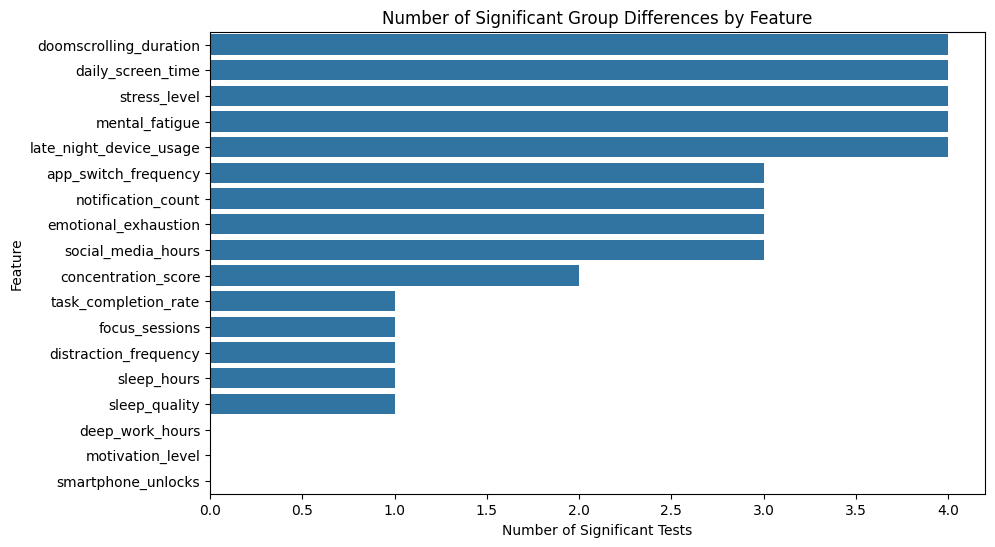

In [100]:
# Trực quan hóa số lượng nhóm có khác biệt thống kê theo từng feature

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_statistical_summary.sort_values(
        by="significant_group_difference",
        ascending=False
    ),
    x="significant_group_difference",
    y="feature"
)

plt.title("Number of Significant Group Differences by Feature")
plt.xlabel("Number of Significant Tests")
plt.ylabel("Feature")

plt.show()

Kết quả kiểm định Kruskal-Wallis cho thấy mức độ khác biệt của các đặc trưng giữa các nhóm sinh viên có sự khác nhau đáng kể.

Một số đặc trưng thể hiện sự khác biệt có ý nghĩa thống kê trên nhiều nhóm phân loại, bao gồm:

- doomscrolling_duration
- daily_screen_time
- stress_level
- mental_fatigue
- late_night_device_usage

Các đặc trưng này đều có kết quả khác biệt có ý nghĩa thống kê đối với cả bốn biến nhóm được xem xét, cho thấy khả năng phản ánh sự khác biệt trong hành vi sử dụng thiết bị số hoặc trạng thái tâm lý giữa các nhóm sinh viên.

Bên cạnh đó, một số đặc trưng như:

- app_switch_frequency
- notification_count
- emotional_exhaustion
- social_media_hours

cũng thể hiện sự khác biệt giữa nhiều nhóm quan sát khác nhau.

Một số biến như:

- deep_work_hours
- motivation_level
- smartphone_unlocks

không cho thấy sự khác biệt có ý nghĩa thống kê theo các nhóm phân loại trong dataset hiện tại. Tuy nhiên, các biến này vẫn được giữ lại để xem xét ở các bước tiếp theo do có ý nghĩa về mặt lý thuyết trong việc mô tả khả năng tập trung, hiệu suất học tập và hành vi sử dụng thiết bị số.

Kết quả Statistical Validation cho thấy nhóm biến liên quan đến mức độ tiếp xúc số và trạng thái tâm lý có khả năng phân biệt tốt giữa các nhóm sinh viên. Tuy nhiên, quyết định lựa chọn đặc trưng cuối cùng cần được đánh giá kết hợp với kết quả Correlation Analysis, Redundancy Analysis và ý nghĩa nghiên cứu.

## 3.3 Redundancy Analysis

Đánh giá mức độ trùng lặp thông tin giữa các đặc trưng nhằm phát hiện các biến có mối quan hệ quá cao và có khả năng cung cấp thông tin tương tự nhau.

Việc kiểm tra redundancy giúp hạn chế việc sử dụng nhiều đặc trưng cùng phản ánh một khía cạnh, từ đó đảm bảo tập đặc trưng cuối cùng có tính đa dạng và khả năng diễn giải tốt hơn.

Sử dụng hệ số tương quan Pearson giữa các biến số.

Ngưỡng đánh giá:

- |correlation| >= 0.7: Có khả năng trùng lặp cao.
- |correlation| < 0.7: Không xem là redundancy nghiêm trọng.

Các biến có tương quan cao chỉ được đánh dấu để xem xét trong bước Feature Selection, không tự động loại bỏ.

In [101]:
# Xác định các cặp biến có tương quan cao

redundancy_threshold = 0.7

redundancy_pairs = (
    correlation_pairs[
        correlation_pairs["abs_correlation"] >= redundancy_threshold
    ]
    .sort_values(
        by="abs_correlation",
        ascending=False
    )
)

redundancy_pairs

# Kiểm tra số lượng cặp feature có tương quan cao

print(
    "Số lượng cặp feature có redundancy:",
    len(redundancy_pairs)
)


Số lượng cặp feature có redundancy: 0


Kết quả phân tích redundancy cho thấy không phát hiện cặp đặc trưng nào có hệ số tương quan tuyệt đối lớn hơn hoặc bằng 0.7.

Cụ thể:

- Số lượng cặp feature có redundancy: 0

Điều này cho thấy các đặc trưng trong bộ dữ liệu khảo sát sinh viên Việt Nam không có hiện tượng trùng lặp thông tin tuyến tính nghiêm trọng.

Các biến trong dataset có mức độ độc lập tương đối, do đó không cần thực hiện loại bỏ đặc trưng dựa trên tiêu chí redundancy tại bước này.

Kết quả này cho phép tiếp tục sử dụng toàn bộ các đặc trưng hợp lệ để thực hiện Feature Ranking, trong đó việc đánh giá cuối cùng sẽ dựa trên sự kết hợp giữa:

- Kết quả Statistical Validation.
- Mức độ liên hệ giữa các biến.
- Ý nghĩa lý thuyết của từng nhóm đặc trưng Digital Burnout.

## 3.4 Feature Ranking

Tổng hợp kết quả từ các bước Feature Validation trước đó nhằm đánh giá mức độ phù hợp của từng đặc trưng trong bộ dữ liệu khảo sát sinh viên Việt Nam.

Feature Ranking trong nghiên cứu này không nhằm tối ưu hóa mô hình học máy mà nhằm xác định các đặc trưng có bằng chứng dữ liệu phù hợp để xây dựng bộ chỉ số Digital Burnout Indicator (DBI).

Các tiêu chí được tổng hợp bao gồm:

- Statistical Evidence:
    - Mức độ khác biệt của feature giữa các nhóm quan sát dựa trên kiểm định Kruskal-Wallis.

- Correlation Evidence:
    - Mức độ liên hệ trung bình của feature với các biến số khác trong dataset.

- Redundancy Status:
    - Kiểm tra feature có bị trùng lặp thông tin với các biến khác hay không.

Dựa trên các tiêu chí trên, mỗi đặc trưng được phân loại thành:

- High:
    Feature có bằng chứng dữ liệu mạnh.

- Medium:
    Feature có một phần bằng chứng thực nghiệm.

- Supporting:
    Feature không nổi bật về mặt thống kê nhưng có vai trò quan trọng về mặt lý thuyết.

In [102]:
# Chuẩn bị kết quả Statistical Validation

statistical_summary = (
    feature_statistical_summary
    .copy()
)

statistical_summary.head()

,feature,significant_group_difference
0,app_switch_frequency,3
1,concentration_score,2
2,daily_screen_time,4
3,deep_work_hours,0
4,distraction_frequency,1


In [103]:
# Tính mức tương quan trung bình của từng feature

correlation_summary = (
    correlation_matrix
    .abs()
    .mean()
    .reset_index()
)

correlation_summary.columns = [
    "feature",
    "mean_correlation"
]

correlation_summary.head()

,feature,mean_correlation
0,daily_screen_time,0.121334
1,social_media_hours,0.110082
2,doomscrolling_duration,0.128239
3,late_night_device_usage,0.159539
4,notification_count,0.118824


In [104]:
# Xác định trạng thái redundancy của feature

redundancy_features = set()

for _, row in redundancy_pairs.iterrows():

    redundancy_features.add(
        row["feature_1"]
    )

    redundancy_features.add(
        row["feature_2"]
    )

feature_redundancy = pd.DataFrame({
    "feature": numeric_features
})

feature_redundancy["redundancy_status"] = (
    feature_redundancy["feature"]
    .apply(
        lambda x:
        "Redundant"
        if x in redundancy_features
        else "No redundancy"
    )
)

feature_redundancy.head()

,feature,redundancy_status
0,daily_screen_time,No redundancy
1,social_media_hours,No redundancy
2,doomscrolling_duration,No redundancy
3,late_night_device_usage,No redundancy
4,notification_count,No redundancy


In [105]:
# Tổng hợp kết quả validation

feature_validation_summary = (
    statistical_summary
    .merge(
        correlation_summary,
        on="feature",
        how="left"
    )
    .merge(
        feature_redundancy,
        on="feature",
        how="left"
    )
)

feature_validation_summary

,feature,significant_group_difference,mean_correlation,redundancy_status
0,app_switch_frequency,3,0.117627,No redundancy
1,concentration_score,2,0.095924,No redundancy
2,daily_screen_time,4,0.121334,No redundancy
3,deep_work_hours,0,0.096900,No redundancy
4,distraction_frequency,1,0.110000,No redundancy
5,doomscrolling_duration,4,0.128239,No redundancy
6,emotional_exhaustion,3,0.140824,No redundancy
7,focus_sessions,1,0.106973,No redundancy
8,late_night_device_usage,4,0.159539,No redundancy
9,mental_fatigue,4,0.121100,No redundancy


In [106]:
# Xác định mức validation rank cho từng feature

def assign_validation_rank(row):

    if (
        row["significant_group_difference"] >= 3
        and row["redundancy_status"] == "No redundancy"
    ):
        return "High"


    elif (
        row["significant_group_difference"] >= 1
        and row["redundancy_status"] == "No redundancy"
    ):
        return "Medium"


    else:
        return "Supporting"

feature_validation_summary["validation_rank"] = (
    feature_validation_summary
    .apply(
        assign_validation_rank,
        axis=1
    )
)

feature_validation_summary

,feature,significant_group_difference,mean_correlation,redundancy_status,validation_rank
0,app_switch_frequency,3,0.117627,No redundancy,High
1,concentration_score,2,0.095924,No redundancy,Medium
2,daily_screen_time,4,0.121334,No redundancy,High
3,deep_work_hours,0,0.096900,No redundancy,Supporting
4,distraction_frequency,1,0.110000,No redundancy,Medium
5,doomscrolling_duration,4,0.128239,No redundancy,High
6,emotional_exhaustion,3,0.140824,No redundancy,High
7,focus_sessions,1,0.106973,No redundancy,Medium
8,late_night_device_usage,4,0.159539,No redundancy,High
9,mental_fatigue,4,0.121100,No redundancy,High


In [107]:
# Sắp xếp theo mức độ validation

rank_order = {
    "High": 1,
    "Medium": 2,
    "Supporting": 3
}

feature_validation_summary["rank_order"] = (
    feature_validation_summary["validation_rank"]
    .map(rank_order)
)

feature_validation_summary = (
    feature_validation_summary
    .sort_values(
        by=[
            "rank_order",
            "significant_group_difference",
            "mean_correlation"
        ],
        ascending=[
            True,
            False,
            False
        ]
    )
    .drop(
        columns="rank_order"
    )
    .reset_index(drop=True)
)

feature_validation_summary

,feature,significant_group_difference,mean_correlation,redundancy_status,validation_rank
0,late_night_device_usage,4,0.159539,No redundancy,High
1,stress_level,4,0.134971,No redundancy,High
2,doomscrolling_duration,4,0.128239,No redundancy,High
3,daily_screen_time,4,0.121334,No redundancy,High
4,mental_fatigue,4,0.121100,No redundancy,High
5,emotional_exhaustion,3,0.140824,No redundancy,High
6,notification_count,3,0.118824,No redundancy,High
7,app_switch_frequency,3,0.117627,No redundancy,High
8,social_media_hours,3,0.110082,No redundancy,High
9,concentration_score,2,0.095924,No redundancy,Medium


Kết quả Feature Ranking cho thấy các đặc trưng trong bộ dữ liệu khảo sát sinh viên Việt Nam có mức độ bằng chứng dữ liệu khác nhau.

Nhóm đặc trưng được xếp loại High Validation bao gồm:

- late_night_device_usage
- stress_level
- doomscrolling_duration
- daily_screen_time
- mental_fatigue
- emotional_exhaustion
- notification_count
- app_switch_frequency
- social_media_hours

Các đặc trưng này thể hiện mức độ phù hợp cao do có sự khác biệt đáng kể giữa nhiều nhóm sinh viên trong kiểm định thống kê và không xuất hiện hiện tượng trùng lặp thông tin.

Nhóm Medium Validation bao gồm:

- concentration_score
- distraction_frequency
- focus_sessions
- sleep_quality
- task_completion_rate
- sleep_hours

Nhóm này vẫn thể hiện giá trị trong việc mô tả trạng thái học tập, khả năng tập trung và quá trình phục hồi của sinh viên, tuy nhiên mức độ khác biệt giữa các nhóm quan sát thấp hơn.

Nhóm Supporting bao gồm:

- motivation_level
- smartphone_unlocks
- deep_work_hours

Các đặc trưng này chưa thể hiện sự khác biệt có ý nghĩa thống kê trong dataset khảo sát hiện tại. Tuy nhiên, các biến vẫn được giữ lại do có vai trò quan trọng trong khung lý thuyết Digital Burnout, đặc biệt liên quan đến khả năng thích ứng nhận thức, hiệu suất học tập và hành vi sử dụng thiết bị số.

Kết quả Feature Ranking cho thấy nhóm biến liên quan đến:

- Mức độ phơi nhiễm số (Digital Exposure).
- Trạng thái tâm lý (Psychological Symptoms).
- Hiệu suất nhận thức và học tập (Cognitive Performance).
- Giấc ngủ và phục hồi (Sleep & Recovery).

đều được đại diện trong bộ đặc trưng.

Bảng Feature Ranking sẽ được sử dụng làm cơ sở kết hợp với khung chỉ số Digital Burnout Indicator (DBI) trong bước Feature Selection.

# 4. Feature Selection

Lựa chọn tập đặc trưng cuối cùng phục vụ xây dựng mô hình Digital Burnout và phát triển khung chỉ số Digital Burnout Indicator (DBI).

Quá trình lựa chọn đặc trưng không chỉ dựa trên kết quả thống kê mà còn xem xét vai trò lý thuyết của từng nhóm chỉ báo trong mô hình Digital Burnout đa chiều.

Một đặc trưng được giữ lại nếu thỏa mãn một trong các điều kiện:

1. Có bằng chứng dữ liệu mạnh:

- Validation Rank = High hoặc Medium.

2. Có vai trò quan trọng trong khung DBI:

- Đại diện cho mức phơi nhiễm số.
- Đại diện cho khả năng nhận thức và học tập.
- Đại diện cho khả năng phục hồi.
- Đại diện cho triệu chứng tâm lý.

## 4.1 Define Final Feature Set

Xác định các đặc trưng được sử dụng trong mô hình dựa trên kết quả Feature Ranking và cấu trúc lý thuyết của Digital Burnout.

In [111]:
# Xác định các Feature được lựa chọn sau quá trình Feature Validation

validated_features = (

    feature_validation_summary[

        feature_validation_summary["validation_rank"].isin(

            [
                "High",
                "Medium",
                "Supporting"
            ]

        )

    ]["feature"]

    .tolist()

)

print(f"Số lượng Feature được lựa chọn: {len(validated_features)}")

print("\nDanh sách Feature:")

for feature in validated_features:

    print(f"- {feature}")

# Chuyển danh sách Feature thành DataFrame để phục vụ lưu trữ

validated_features_df = pd.DataFrame(

    {
        "feature": validated_features,
        "selected": True
    }
)

display(validated_features_df)

Số lượng Feature được lựa chọn: 18

Danh sách Feature:
- late_night_device_usage
- stress_level
- doomscrolling_duration
- daily_screen_time
- mental_fatigue
- emotional_exhaustion
- notification_count
- app_switch_frequency
- social_media_hours
- concentration_score
- distraction_frequency
- focus_sessions
- sleep_quality
- task_completion_rate
- sleep_hours
- motivation_level
- smartphone_unlocks
- deep_work_hours


,feature,selected
0,late_night_device_usage,True
1,stress_level,True
2,doomscrolling_duration,True
3,daily_screen_time,True
4,mental_fatigue,True
5,emotional_exhaustion,True
6,notification_count,True
7,app_switch_frequency,True
8,social_media_hours,True
9,concentration_score,True


In [112]:
# Xuất danh sách Validated Features

output_path = Path(
    "../../data/processed/vietnam_dataset/validated_features.csv"
)

validated_features_df.to_csv(
    output_path,
    index=False,
    encoding="utf-8-sig"
)

print(f"\nĐã lưu kết quả tại: {output_path}")


Đã lưu kết quả tại: ..\..\data\processed\vietnam_dataset\validated_features.csv


## 4.2 Survey Feature - Candidate Indicator Mapping

Thiết lập mối liên hệ giữa các đặc trưng khảo sát đã được xác thực (Validated Features) với các Candidate Indicators được xây dựng từ tổng quan tài liệu, nhằm đảm bảo mỗi đặc trưng sử dụng trong mô hình đều có cơ sở lý thuyết và thuộc một chiều (dimension) cụ thể của Digital Burnout Indicator (DBI).

In [ ]:
# Tải Candidate Indicators

candidate_indicator_path = Path(
    "../../data/processed/candidate_indicators.csv"
)
candidate_indicators = pd.read_csv(
    candidate_indicator_path
)

print("Đã tải Candidate Indicators.")

In [ ]:
# Xây dựng Mapping giữa Feature và Candidate Indicator

feature_indicator_mapping = {

    # Digital Exposure

    "daily_screen_time": "DE01",
    "social_media_hours": "DE02",
    "app_switch_frequency": "DE02",
    "notification_count": "DE04",
    "smartphone_unlocks": "DE04",
    "late_night_device_usage": "DE05",
    "doomscrolling_duration": "PS02",

    # Cognitive Performance

    "distraction_frequency": "CP03",
    "concentration_score": "CP03",
    "focus_sessions": "CP03",
    "deep_work_hours": "CP02",
    "task_completion_rate": "CP04",

    # Sleep & Recovery

    "sleep_hours": "SR01",
    "sleep_quality": "SR05",

    # Psychological Symptoms

    "stress_level": "PS03",
    "emotional_exhaustion": "PS03",
    "mental_fatigue": "PS04"

}

In [ ]:
# Xác định loại Mapping

mapping_type = {

    "daily_screen_time": "Direct",
    "social_media_hours": "Proxy",
    "app_switch_frequency": "Direct",
    "notification_count": "Direct",
    "smartphone_unlocks": "Proxy",
    "late_night_device_usage": "Direct",
    "doomscrolling_duration": "Proxy",
    "distraction_frequency": "Direct",
    "concentration_score": "Inverse",
    "focus_sessions": "Proxy",
    "deep_work_hours": "Proxy",
    "task_completion_rate": "Proxy",
    "sleep_hours": "Direct",
    "sleep_quality": "Direct",
    "stress_level": "Proxy",
    "emotional_exhaustion": "Direct",
    "mental_fatigue": "Direct"

}

In [ ]:
# Chuyển Mapping thành DataFrame

mapping_table = pd.DataFrame({

    "feature": feature_indicator_mapping.keys(),
    "indicator_id": feature_indicator_mapping.values()

})

mapping_table["mapping_type"] = (

    mapping_table["feature"]
    .map(mapping_type)

)

In [ ]:
# Ghép với Candidate Indicators

mapping_table = mapping_table.merge(

    candidate_indicators[

        [
            "indicator_id",
            "dbi_dimension",
            "indicator_name"
        ]

    ],

    on="indicator_id",
    how="left"

)

mapping_table = mapping_table[

    [
        "feature",
        "indicator_id",
        "indicator_name",
        "dbi_dimension",
        "mapping_type"
    ]

]

display(mapping_table)

In [ ]:
# Thống kê số lượng Feature theo từng DBI Dimension

dimension_summary = (

    mapping_table
    .groupby("dbi_dimension")
    .size()
    .reset_index(
        name="number_of_features"
    )

)

display(dimension_summary)

Kết quả Feature–Indicator Mapping cho thấy toàn bộ 17 đặc trưng được lựa chọn sau quá trình Feature Validation đều có thể liên kết với các Candidate Indicators được xây dựng từ tổng quan tài liệu. Trong đó, nhóm Digital Exposure chiếm nhiều đặc trưng nhất (6), tiếp theo là Cognitive Performance (5), Psychological Symptoms (4) và Sleep & Recovery (2). Điều này phản ánh rằng bộ dữ liệu khảo sát tập trung chủ yếu vào hành vi sử dụng thiết bị số và tác động của chúng đến hiệu suất nhận thức cũng như trạng thái tâm lý của sinh viên. Ngoài các chỉ số được đo lường trực tiếp (Direct), một số đặc trưng được sử dụng như biến đại diện (Proxy) hoặc có quan hệ nghịch (Inverse) với Candidate Indicators nhằm phản ánh đầy đủ các khái niệm lý thuyết. Kết quả mapping này tạo nền tảng để xây dựng Digital Burnout Indicator (DBI) Framework trong giai đoạn nghiên cứu tiếp theo.

In [ ]:
# Xuất kết quả Feature - Candidate Indicator Mapping

output_path = Path(
    "../../data/processed/feature_indicator_mapping.csv"
)

mapping_table.to_csv(
    output_path,
    index=False,
    encoding="utf-8-sig"
)

print(f"Đã lưu kết quả tại: {output_path}")